In [6]:
# Import libraries
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import lc_reconstruction_analysis.utils as utils
import lc_reconstruction_analysis.clustering as clustering
import lc_reconstruction_analysis.axon as axon
import lc_reconstruction_analysis.graph as graph
import lc_reconstruction_analysis.correlation as correlation
import lc_reconstruction_analysis.visualization as visualization
import lc_reconstruction_analysis.markov as markov

In [2]:
# Define path to data
SINGLE_CELL_DATA_DIR = Path("/data/LC_Snapshots")
DATA_DIR = Path("/data/")

# Increase recursion limit, needed when computing clean_structure annotations
sys.setrecursionlimit(10000)

# Used to plot inside jupyter notebooks
%matplotlib inline

# Number of samples for random walk models
# set to 400 for major run, smaller for faster exploration
NUM_SAMPLES=400 

# Load Data

In [3]:
# Load data frame of cells, and networkx graphs
dataDF, graphs = utils.load_cells(SINGLE_CELL_DATA_DIR)
unnormalized_df = clustering.build_length_df(dataDF, graphs, DATA_DIR, normalize_df = False)

Missing structure dendrite for /data/685221_12_5_24/Complete_annotated/N064-68221-JN.json
Missing structure dendrite for /data/685221_12_5_24/Complete_annotated/N025-685221-PG.json
Missing structure axon for /data/685221_12_5_24/Complete_annotated/N064-685221-JN.json
Missing structure dendrite for /data/685221_12_5_24/Complete_annotated/N051-685221 -YP.json
Missing structure dendrite for /data/648434_12_5_24/Complete_annotated/N024-648434-SS.json
Error finding structures for: N025-685221-PG, dropping from dataframe
Error finding structures for: N064-68221-JN, dropping from dataframe
Error finding structures for: N064-685221-JN, dropping from dataframe
Error finding structures for: N051-685221 -YP, dropping from dataframe
Error finding structures for: N024-648434-SS, dropping from dataframe


# Plot correlation matrix and shuffled data

In [4]:
# Build Correlation Matrix for data based on axon length in each brain region
df = clustering.build_length_df(dataDF, graphs, DATA_DIR)
sorted_columns = ['OLF','Isocortex','HPF','CTXsp','CNU','TH','HY','MB','CB','P','MY','Other']
df = df[sorted_columns]

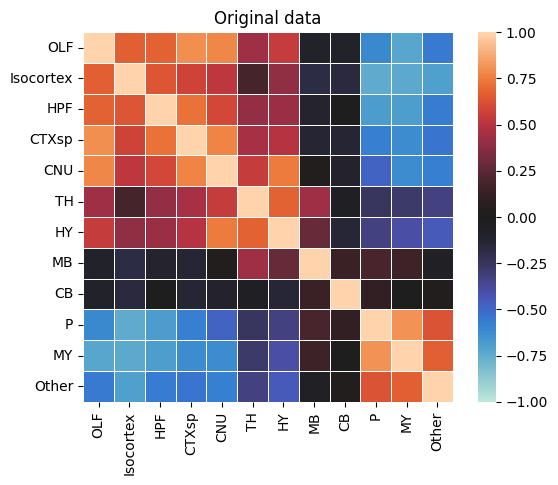

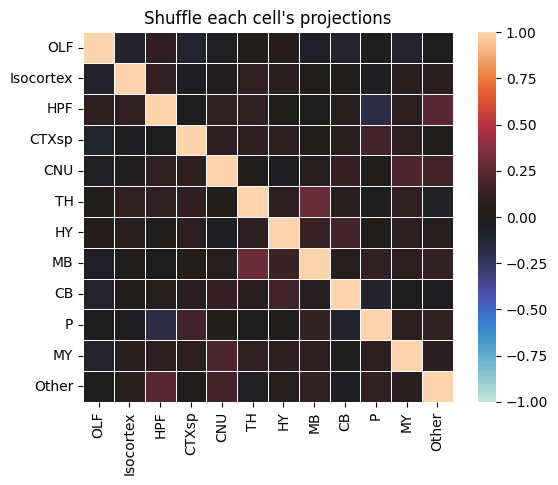

In [7]:
correlation.plot_correlation(df)
fig1 = plt.gcf()
fig1.savefig('/results/fig1_correlation_data.svg')
correlation.plot_shuffle_row(df)
fig2 = plt.gcf()
fig2.savefig('/results/fig1_correlation_data_shuffle.svg')

# Build Markov Transition Matrix

We can construct a markov transition matrix by counting the number of edges that go from region A to region B, including staying in the same place. We can similarly compute the probability of terminating an axon segment, or branching and making a new segment. 

In [8]:
edges, terminals, branches = markov.build_transition_matrix(dataDF, graphs, DATA_DIR)

  2%|▏         | 3/135 [00:01<01:07,  1.96it/s]

N001-685221-PG maximum recursion depth exceeded in comparison


  7%|▋         | 9/135 [00:05<01:31,  1.37it/s]

N016-685221-PG maximum recursion depth exceeded in comparison


100%|██████████| 135/135 [00:59<00:00,  2.26it/s]


In [9]:
graphs = axon.add_all_wire_lengths(dataDF, graphs)
branch_df,node_df = axon.build_combined_branch_table(dataDF, graphs)

  2%|▏         | 3/135 [00:02<01:34,  1.39it/s]

problem N001-685221-PG, 'clean_structure'


  7%|▋         | 9/135 [00:09<02:24,  1.15s/it]

problem N016-685221-PG, 'clean_structure'


100%|██████████| 135/135 [01:46<00:00,  1.27it/s]


In [10]:
A, An, summary = markov.build_summary(edges, terminals, branches, clean_transitions=['SC'])

### Viewing the transition matrix
We can view the transition matrix, the self-edges have the highest probability

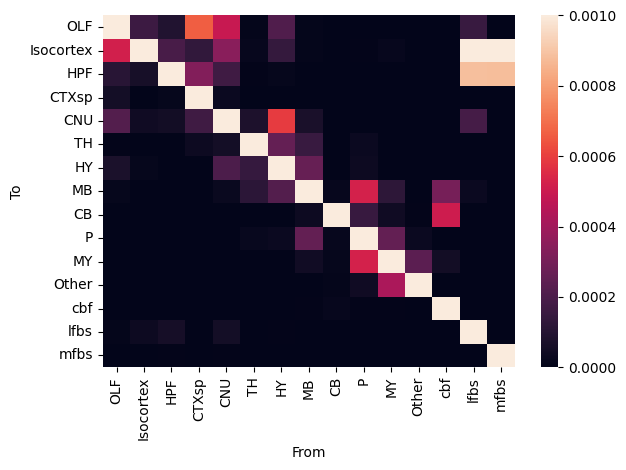

In [11]:
markov.plot_transition_matrix(An)
fig3 = plt.gcf()
fig3.savefig('/results/fig2_markov_transition_matrix.svg')

### Viewing the transition matrix as a graph
We can instead view the transition matrix as a graph. I have omitted the self-weights for clarity. Edge thickness represents weight.

In [12]:
pos = utils.get_roi_centroids(DATA_DIR)

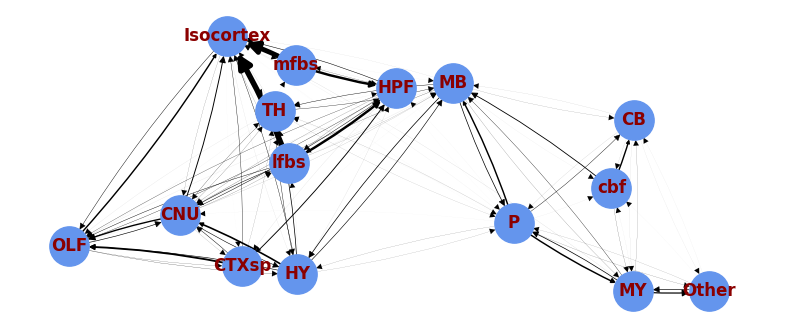

In [13]:
graph.plot_graph_from_adjacency(An,pos)
fig4 = plt.gcf()
fig4.savefig('/results/fig2_transition_matrix_graph.svg')

# Pure Markov Model (Model Version 1)

Our first generative model is a pure markov model. The probability of transitioning between regions, branching, or terminating, depends only on the current location. 


In [14]:
samples_v1, branches_v1 = markov.simulate_graph(An, summary, samples=NUM_SAMPLES, version=1)

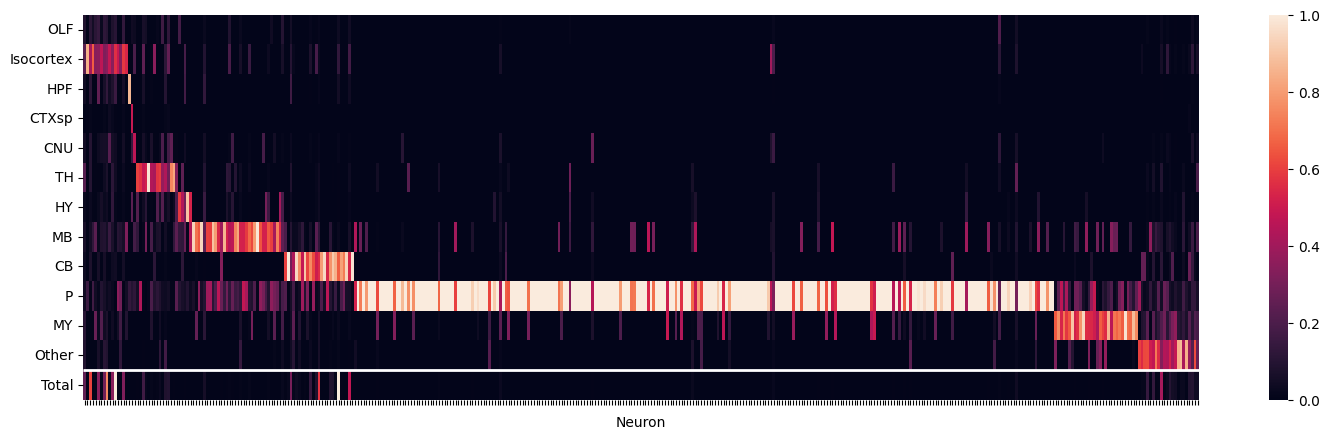

In [15]:
markov.plot_heatmap(samples_v1)
fig5 = plt.gcf()
fig5.savefig('/results/fig3_v3_heatmap.svg')

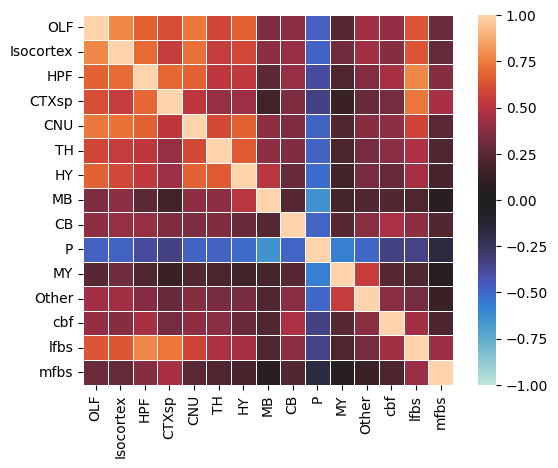

In [16]:
markov.plot_correlation(samples_v1)
fig6 = plt.gcf()
fig6.savefig('/results/fig3_v3_correlation.svg')

### Interpretation

The pure markov model fails to capture several aspects of the data, primarily the model axons have too much axon length in the Pons, and are overall too short. The pure markov model will generate an exponential distribution of lengths. Since this doesn't appear to match the data, we should determine what the distribution of axon lengths is in the real data

# Viewing the branching and termination rates

If we look at the rates of branching and termination across brain regions, we see they are closely matched, with termination rates slightly larger than branching rates which prevents run-away growth. Error bars are binomial 95% confidence intervals

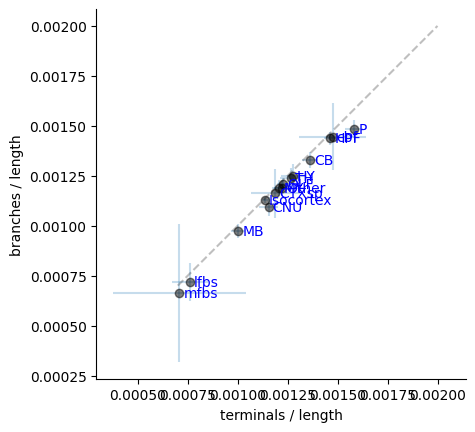

In [17]:
markov.plot_rates(summary)
fig7 = plt.gcf()
fig7.savefig('/results/fig4_branching_and_termination_rates.svg')

# Are branching and termination rates fixed?

Why does the markov model fail to capture the length distribution observed in cells? One possibility is to describe the cells as markov chains with branching/termination rates that vary over time. To assess this, we can ask if branching and termination rates depend on wire-length from soma.

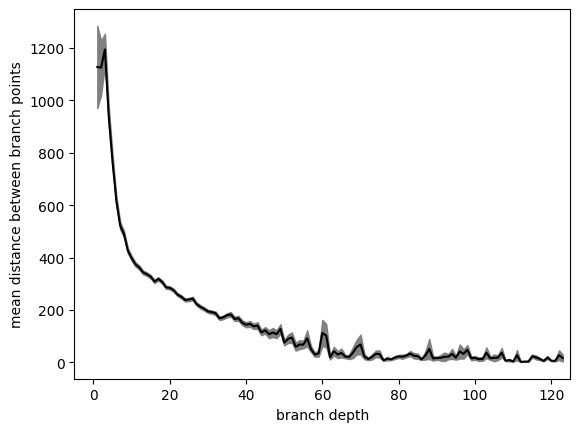

In [18]:
markov.plot_length_by_depth(branch_df, aggregate='mean')
fig8 = plt.gcf()
fig8.savefig('/results/fig4_length_by_depth.svg')

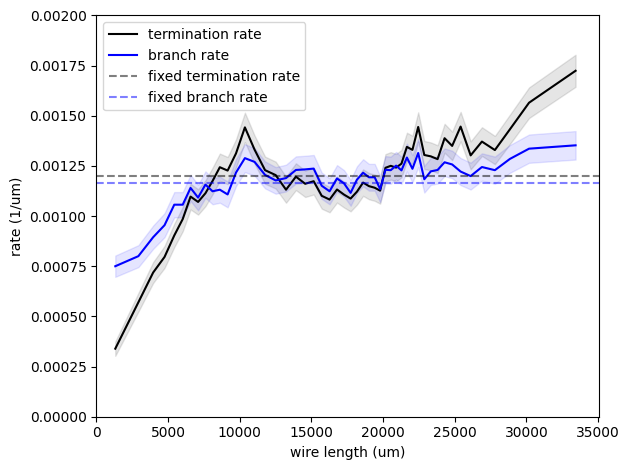

In [19]:
markov.plot_rates_by_length(node_df, summary)
fig9 = plt.gcf()
fig9.savefig('/results/fig4_rates_by_length.svg')

# Markov Model with length dependent branching and termination (Model Version 2)

In [20]:
samples_v2, branches_v2 = markov.simulate_graph(An, summary, samples=NUM_SAMPLES, version=2,node_df=node_df)

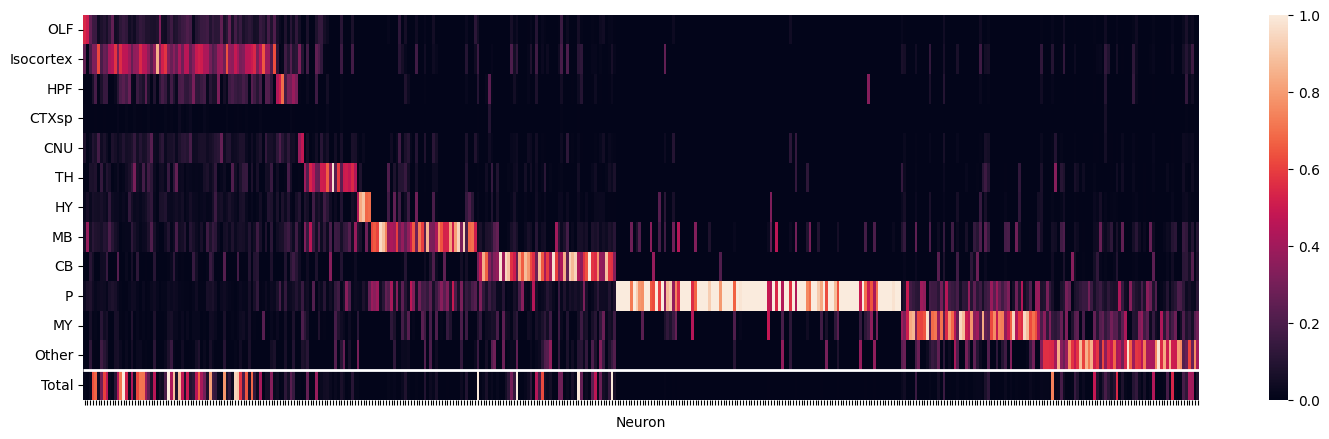

In [21]:
markov.plot_heatmap(samples_v2)
fig10 = plt.gcf()
fig10.savefig('/results/fig5_v4_heatmap.svg')

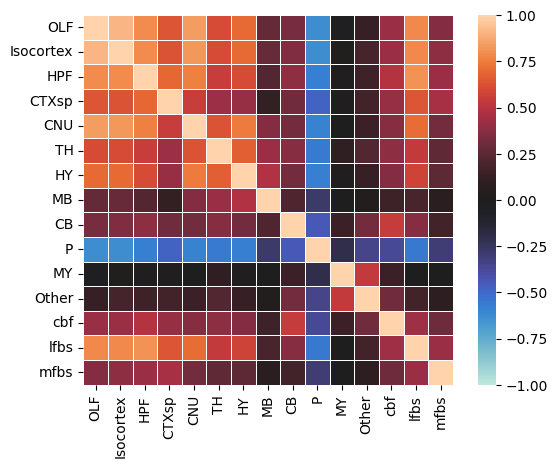

In [22]:
markov.plot_correlation(samples_v2)
fig11 = plt.gcf()
fig11.savefig('/results/fig5_v4_correlation.svg')

# Fiting the axon length distribution of LC neurons

We can fit a weibull distribution to the total length of axons (summing across branches in each cell), and use the spinal-cord projecting cells as censored observations. 

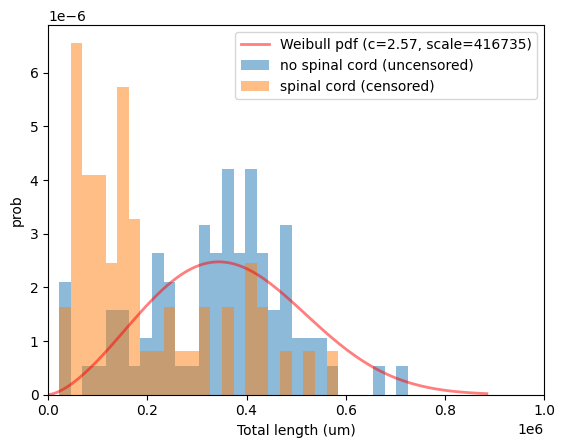

In [23]:
incompleteSC = dataDF.query('not completeSC & isSpinalProjecting')['Graph'].values
markov.fit_length_distribution(unnormalized_df, incompleteSC, bins=30)
fig12 = plt.gcf()
fig12.savefig('/results/fig6_length_distribution_weibull.svg')

# Markov Model with length dependent termination/branching rates, a minimum length, and a Weibull Renewal global stop process

In [24]:
samples_v4, branches_v4_c5 = markov.simulate_graph(
    An, 
    summary, 
    samples=NUM_SAMPLES, 
    version=4, 
    node_df=node_df, 
    min_length=10000,
    scale=412642,
    s=3.00
    )

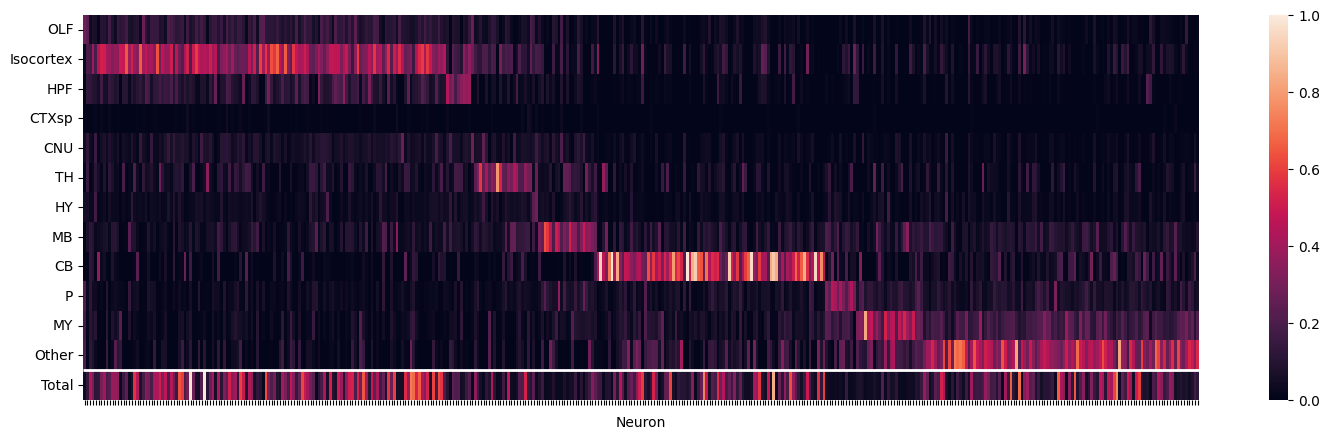

In [25]:
markov.plot_heatmap(samples_v4)
fig13 = plt.gcf()
fig13.savefig('/results/fig6_v5_heatmap.svg')

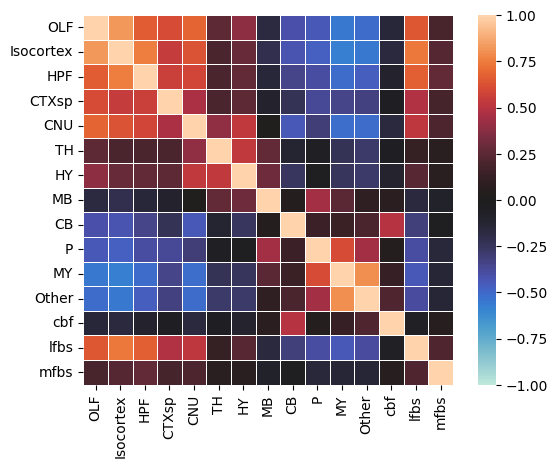

In [26]:
markov.plot_correlation(samples_v4)
fig14 = plt.gcf()
fig14.savefig('/results/fig7_v5_heatmap.svg')

# Final comparison

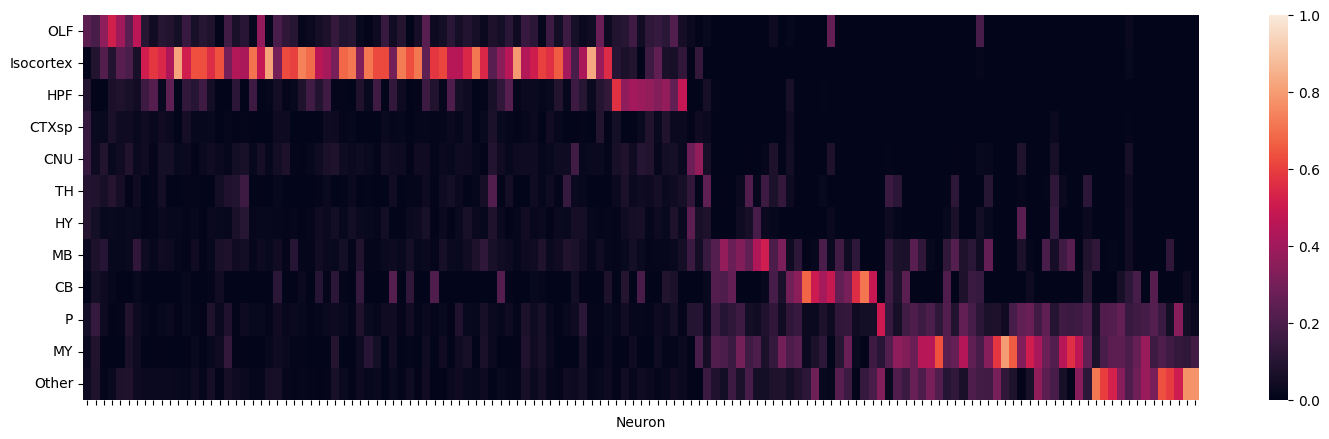

In [28]:
visualization.plot_heatmap(dataDF, df,vmax=1)
fig15 = plt.gcf()
fig15.savefig('/results/fig8_data_heatmap.svg')

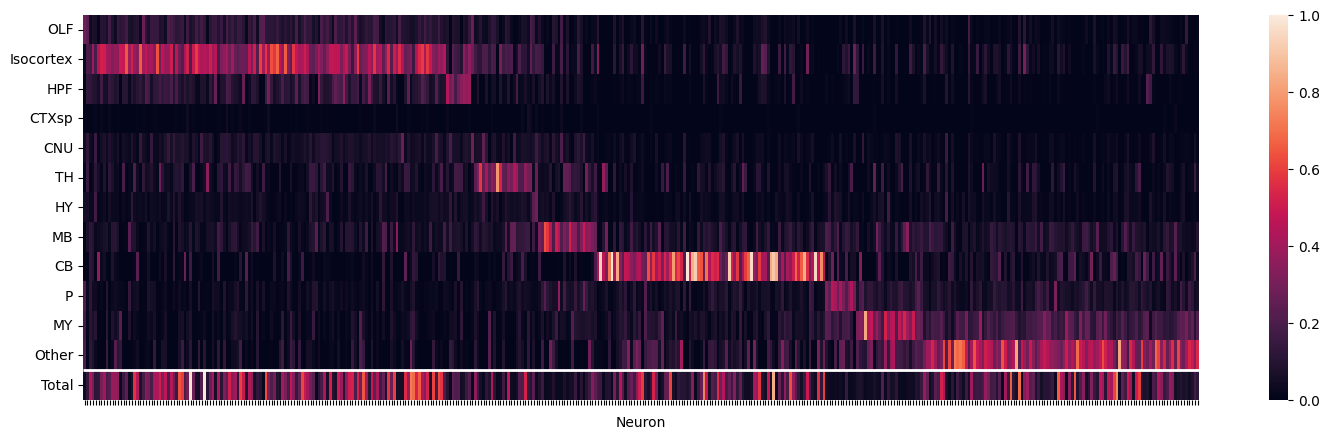

In [30]:
markov.plot_heatmap(samples_v4)
fig16 = plt.gcf()
fig16.savefig('/results/fig8_final_heatmap.svg')

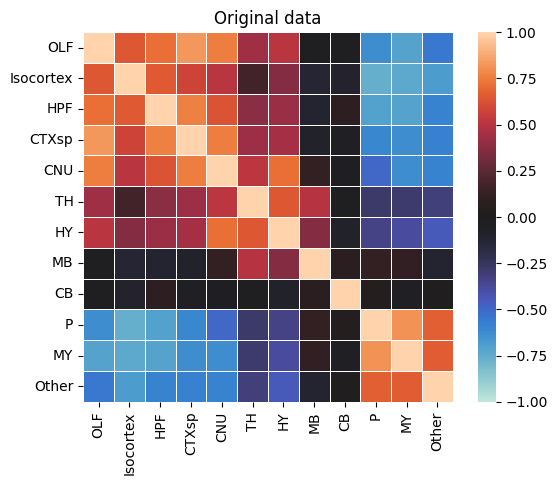

In [27]:
correlation.plot_correlation(df)
fig20 = plt.gcf()
fig20.savefig('/results/fig8_data_correlation.svg')

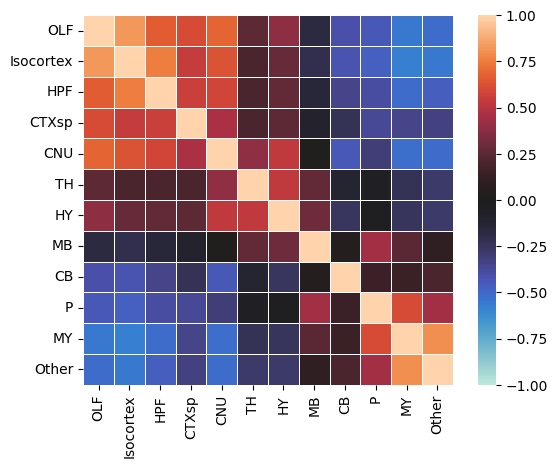

In [31]:
markov.plot_correlation(samples_v4, match_data=True)
fig17 = plt.gcf()
fig17.savefig('/results/fig8_final_correlation.svg')